Compare repetition-centered lag-CRP curves for observed data and a matched control dataset.

Adjust `control_trial_query` to define alternative control populations.

Set `repetition_index` to 0 or 1 to focus on specific presentations.


In [1]:
import matplotlib.pyplot as plt
import os

from jaxcmr.analyses.repcrp import (
    plot_rep_crp,
    subject_rep_crp,
    test_first_second_bias,
    test_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/Lohnas2025_BlendPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "Lohnas2025_BlendPositionalCMRNoStop_rerun_best_of_1_repcrp.png"
mixed_trial_query = "data['list_type'] == 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
ylim = [0.05, 0.32]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


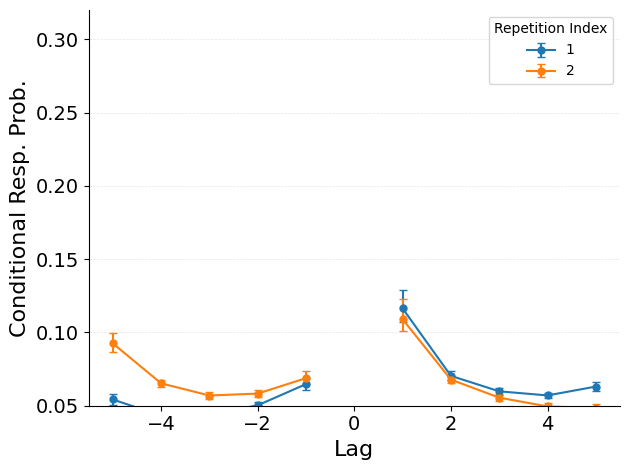

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


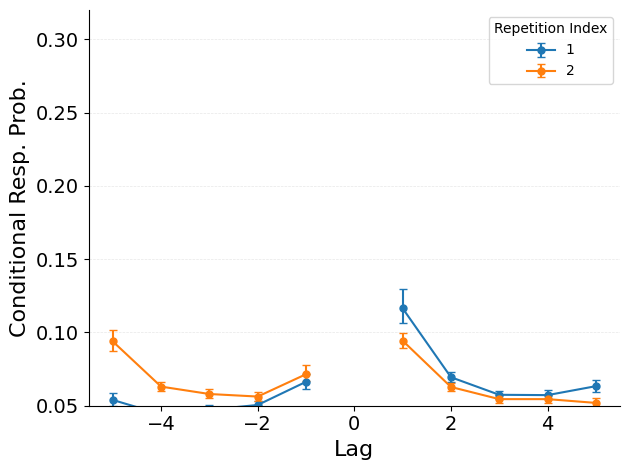

In [5]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")
plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [6]:
observed_crp = subject_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    0.598     0.5502 |  27122.0     0.6975 |     0.0009
   -4 |   -0.478     0.6328 |  27251.5     0.8988 |    -0.0005
   -3 |   -2.428     0.0157 |  24127.0     0.0237 |    -0.0032
   -2 |    0.012     0.9904 |  27984.5     0.9301 |     0.0000
   -1 |   -0.923     0.3565 |  26080.0     0.3264 |    -0.0014
    0 |      nan        nan |      nan        nan |        nan
    1 |   -0.317     0.7513 |  27151.0     0.5772 |    -0.0007
    2 |    0.854     0.3938 |  26842.0     0.4644 |     0.0011
    3 |    2.166     0.0310 |  24302.0     0.0246 |     0.0026
    4 |    0.046     0.9634 |  26113.0     0.2180 |     0.0001
    5 |    0.024     0.9810 |  27665.0     0.8618 |     0.0000

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:507: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:518: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [7]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    0.561     0.5754 |  26351.0     0.3132 |     0.0017
   -4 |   -1.706     0.0889 |  25202.0     0.0977 |    -0.0030
   -3 |   -1.123     0.2624 |  24981.0     0.0619 |    -0.0025
   -2 |   -1.279     0.2018 |  25785.0     0.1843 |    -0.0022
   -1 |    0.330     0.7417 |  28158.0     0.9329 |     0.0008
    0 |      nan        nan |      nan        nan |        nan
    1 |   -2.505     0.0127 |  24213.0     0.0216 |    -0.0130
    2 |   -1.984     0.0480 |  24436.0     0.0368 |    -0.0039
    3 |    0.770     0.4421 |  26376.0     0.2783 |     0.0014
    4 |    2.310     0.0215 |  23303.0     0.0050 |     0.0047
    5 |    1.635     0.10

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:576: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:587: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
